<a href="https://colab.research.google.com/github/haru452/anime_super-resolution/blob/main/drizzle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== 画像0を基準にして位置合わせを試します ===
  画像1: dx=1946.34, dy=1248.32
  画像2: dx=5761.77, dy=4610.28
  画像3: dx=2357.34, dy=1767.09
  画像4: dx=2658.23, dy=2260.89
  画像5: dx=726.04, dy=-1461.91
  画像6: dx=2228.63, dy=1503.04
  画像7: dx=2602.92, dy=1469.23
  画像8: dx=1942.71, dy=1397.76
  画像9: dx=2275.78, dy=1576.83
  画像10: dx=1499.81, dy=-407.70
画像1: 除外 (Hが物理的にありえない値(scale=(0.3543,0.3013), shear=0.4999))
画像2: 除外 (重なり不足, Hが相対的な外れ値(scale=(66.7637,50.4137), shear=74.1882), Hが物理的にありえない値(scale=(66.7637,50.4137), shear=74.1882))
画像3: 除外 (重なり不足, Hが物理的にありえない値(scale=(0.6711,1.5850), shear=1.6219))
画像4: 除外 (重なり不足, Hが物理的にありえない値(scale=(1.0328,0.8316), shear=1.3318))
画像5: 除外 (Hが物理的にありえない値(scale=(0.8164,0.2436), shear=0.9529))
画像6: 除外 (重なり不足, Hが相対的な外れ値(scale=(0.5702,1.7986), shear=1.7425), Hが物理的にありえない値(scale=(0.5702,1.7986), shear=1.7425))
画像7: 除外 (重なり不足, Hが物理的にありえない値(scale=(0.5188,0.8023),

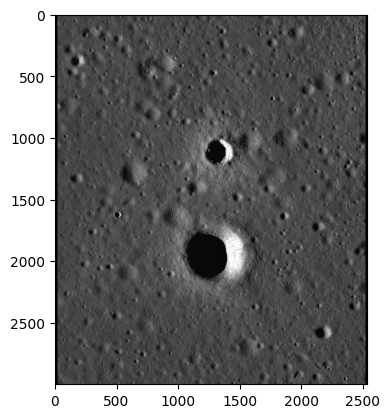

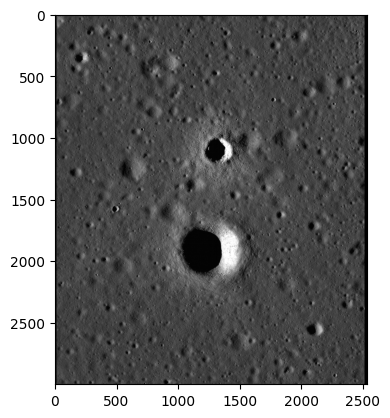

Shift-and-Add(ドリズル)開始: 入力2枚, 出力サイズ(6000, 5064)
  画像0: 重ね合わせ完了
  画像1: 重ね合わせ完了


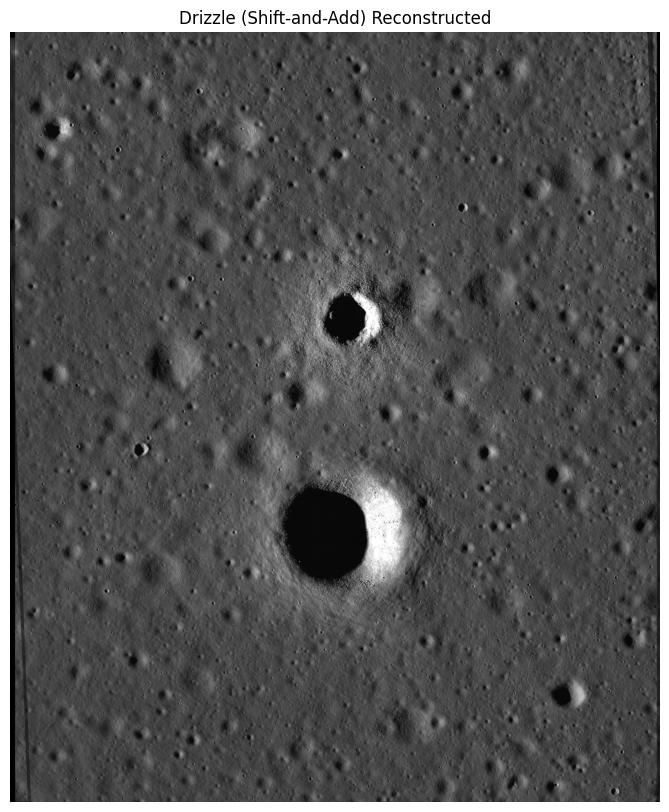

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23492 (\N{CJK UNIFIED IDEOGRAPH-5BC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.pri

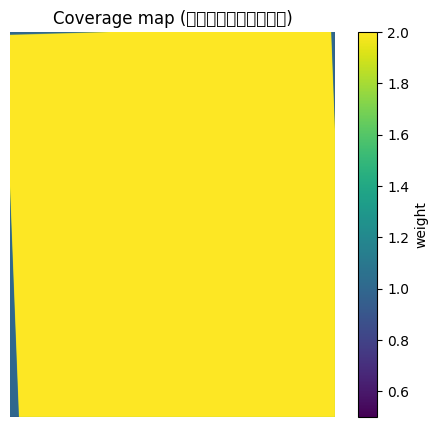

In [ ]:
import glob
import os
import cv2
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

IMAGE_DIR = '/content/drive/My Drive/Graduate/Craters0728'

"""## 位置合わせ"""

class SobelPreprocessor:
    @staticmethod
    def apply(img):
        grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = np.sqrt(grad_x**2 + grad_y**2)
        return cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

class FeatureMatcher:
    def __init__(self):
        self.detector = cv2.SIFT_create()
        index_params = dict(algorithm=1, trees=5)
        search_params = dict(checks=50)
        self.matcher = cv2.FlannBasedMatcher(index_params, search_params)

    def detect_and_match(self, img1, img2):
        sobel1 = SobelPreprocessor.apply(img1)
        sobel2 = SobelPreprocessor.apply(img2)
        kp1, des1 = self.detector.detectAndCompute(sobel1, None)
        kp2, des2 = self.detector.detectAndCompute(sobel2, None)
        matches = self.matcher.knnMatch(des1, des2, k=2)
        good = [m for m, n in matches if m.distance < 0.75 * n.distance]
        return kp1, kp2, good


class ImageAligner:
    def __init__(self):
        self.matcher = FeatureMatcher()

    def align_full(self, img1, img2, debug_label=None):
        """
        img1: 基準画像 (base)
        img2: 位置合わせ対象画像
        戻り値のHは「img2の座標 -> img1(base)の座標」への変換行列。
        """
        kp1, kp2, good_matches = self.matcher.detect_and_match(img1, img2)

        if len(good_matches) < 4:
            raise RuntimeError("Not enough matches to compute homography.")

        pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        H, mask = cv2.findHomography(
            pts2, pts1, cv2.RANSAC,
            ransacReprojThreshold=3.0, maxIters=5000, confidence=0.995,
        )
        if H is None:
            raise RuntimeError("Homography computation failed.")

        # デバッグ用: マッチング結果を可視化したい場合はここで有効化
        if debug_label is not None:
            sobel1 = SobelPreprocessor.apply(img1)
            sobel2 = SobelPreprocessor.apply(img2)
            inlier_matches = [m for m, keep in zip(good_matches, mask.ravel()) if keep]
            img_matches = cv2.drawMatches(
                sobel1, kp1, sobel2, kp2, inlier_matches, None,
                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
            )
            plt.figure(figsize=(15, 7))
            plt.imshow(img_matches, cmap='gray')
            plt.title(f"Inlier matches: {debug_label} (n={len(inlier_matches)})")
            plt.axis('off')
            plt.show()

        origin_pt = np.array([[[0.0, 0.0]]], dtype=np.float32)
        transformed_origin = cv2.perspectiveTransform(origin_pt, H)
        dx = transformed_origin[0][0][0]
        dy = transformed_origin[0][0][1]

        return H, dx, dy


# パスを取得
path = glob.glob(os.path.join(IMAGE_DIR, '*.tif'))
path = sorted(path, key=os.path.getmtime)

raw_images = []
for p in path:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        raw_images.append(img)
    else:
        print(f"画像の読み込みに失敗しました: {p}")

if not raw_images:
    raise RuntimeError(f"画像が見つかりませんでした。IMAGE_DIR='{IMAGE_DIR}' を確認してください.")

aligner = ImageAligner()

# デバッグ用: マッチング可視化をしたい場合はTrueにする
DEBUG_SHOW_MATCHES = False


def align_all_to_base(raw_images, base_idx, aligner):
    base_img = raw_images[base_idx]
    n = len(raw_images)
    offsets = [None] * n
    H_list = [None] * n
    offsets[base_idx] = (0.0, 0.0)
    H_list[base_idx] = np.eye(3, dtype=np.float64)

    for i, img in enumerate(raw_images):
        if i == base_idx:
            continue
        try:
            label = f"base={base_idx}, img={i}" if DEBUG_SHOW_MATCHES else None
            H, dx, dy = aligner.align_full(base_img, img, debug_label=label)
        except RuntimeError as e:
            print(f"  画像{i}: 位置合わせ失敗 ({e})")
            offsets[i] = (float('inf'), float('inf'))
            H_list[i] = np.eye(3, dtype=np.float64)
            continue
        print(f"  画像{i}: dx={dx:.2f}, dy={dy:.2f}")
        offsets[i] = (dx, dy)
        H_list[i] = H

    return offsets, H_list

"""## いらない画像の抽出"""

def filter_valid_images_statistical(images, offsets, H_list, base_idx=0,
                                      min_overlap_ratio=0.3, outlier_threshold=3.0):
    h, w = images[0].shape[:2]

    scales_x, scales_y, shears = [], [], []
    for H in H_list:
        A = H[:2, :2]
        scales_x.append(np.sqrt(A[0, 0] ** 2 + A[1, 0] ** 2))
        scales_y.append(np.sqrt(A[0, 1] ** 2 + A[1, 1] ** 2))
        shears.append(abs(A[0, 1]) + abs(A[1, 0]))

    scales_x = np.array(scales_x)
    scales_y = np.array(scales_y)
    shears = np.array(shears)

    def is_outlier(values, idx, thresh):
        median = np.median(values)
        mad = np.median(np.abs(values - median)) + 1e-8
        return abs(values[idx] - median) / mad > thresh

    valid_indices = []
    for i, (dx, dy) in enumerate(offsets):
        if i == base_idx:
            valid_indices.append(i)
            continue

        overlap_w = w - abs(dx)
        overlap_h = h - abs(dy)
        overlap_ratio = (overlap_w * overlap_h) / (w * h) if overlap_w > 0 and overlap_h > 0 else 0.0

        sx_outlier = is_outlier(scales_x, i, outlier_threshold)
        sy_outlier = is_outlier(scales_y, i, outlier_threshold)
        sh_outlier = is_outlier(shears, i, outlier_threshold)
        h_ok = not (sx_outlier or sy_outlier or sh_outlier)

        if overlap_ratio >= min_overlap_ratio and h_ok:
            valid_indices.append(i)
            print(f"画像{i}: 採用 (scale=({scales_x[i]:.4f},{scales_y[i]:.4f}), shear={shears[i]:.4f})")
        else:
            reason = []
            if overlap_ratio < min_overlap_ratio:
                reason.append("重なり不足")
            if not h_ok:
                reason.append(f"Hが外れ値(scale=({scales_x[i]:.4f},{scales_y[i]:.4f}), shear={shears[i]:.4f})")
            print(f"画像{i}: 除外 ({', '.join(reason)})")

    return valid_indices


MIN_OVERLAP_RATIO = 0.3
OUTLIER_THRESHOLD = 3.0  # 6.0だと緩すぎて歪んだHも通ってしまうため厳しめに変更
MIN_REQUIRED_IMAGES = 6

best_base_idx = None
best_valid_indices = []
best_offsets = None
best_H_list = None

for base_idx in range(len(raw_images)):
    print(f"\n=== 画像{base_idx}を基準にして位置合わせを試します ===")
    offsets, H_list = align_all_to_base(raw_images, base_idx, aligner)
    valid_indices = filter_valid_images_statistical(
        raw_images, offsets, H_list, base_idx=base_idx,
        min_overlap_ratio=MIN_OVERLAP_RATIO,
        outlier_threshold=OUTLIER_THRESHOLD,
    )
    print(f"--- 画像{base_idx}を基準: 採用 {len(valid_indices)}枚 {valid_indices} ---")

    if len(valid_indices) > len(best_valid_indices):
        best_base_idx = base_idx
        best_valid_indices = valid_indices
        best_offsets = offsets
        best_H_list = H_list

    if len(best_valid_indices) >= MIN_REQUIRED_IMAGES:
        print(f"十分な枚数({len(best_valid_indices)}枚)が確保できたので探索を打ち切ります.")
        break
else:
    print(
        f"\nどの基準画像を試しても目標の{MIN_REQUIRED_IMAGES}枚には届きませんでした."
        f"最も採用枚数が多かった基準画像(画像{best_base_idx})を使用します."
    )

base_idx = best_base_idx
valid_indices = best_valid_indices
offsets = best_offsets
H_list = best_H_list

print(f"\n>>> 最終的に画像{base_idx}を基準として採用します。有効画像: {valid_indices} ({len(valid_indices)}枚)")

filtered_images = [raw_images[i] for i in valid_indices]
filtered_H_list = [H_list[i] for i in valid_indices]

"""## 重なり領域(オーバーラップ)の計算 (回転・スケールも考慮)"""

def compute_overlap_bbox(images, H_list, base_shape):
    """
    各画像の四隅をHで変換し、base画像座標系での共通重なり矩形(軸並行)を求める。
    単純なdx,dyの並進だけでなく、回転・スケールも考慮した重なり範囲になる。
    """
    hb, wb = base_shape
    x1s, x2s, y1s, y2s = [], [], [], []

    for img, H in zip(images, H_list):
        h, w = img.shape[:2]
        corners = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype=np.float32).reshape(-1, 1, 2)
        warped_corners = cv2.perspectiveTransform(corners, H).reshape(-1, 2)
        x1s.append(warped_corners[:, 0].min())
        x2s.append(warped_corners[:, 0].max())
        y1s.append(warped_corners[:, 1].min())
        y2s.append(warped_corners[:, 1].max())

    crop_x1 = max(0.0, max(x1s))
    crop_x2 = min(float(wb), min(x2s))
    crop_y1 = max(0.0, max(y1s))
    crop_y2 = min(float(hb), min(y2s))

    return crop_x1, crop_x2, crop_y1, crop_y2


base_h, base_w = raw_images[base_idx].shape[:2]
crop_x1, crop_x2, crop_y1, crop_y2 = compute_overlap_bbox(filtered_images, filtered_H_list, (base_h, base_w))

if crop_x2 <= crop_x1 or crop_y2 <= crop_y1:
    raise RuntimeError("有効な重なり領域が見つかりませんでした。位置合わせ結果を確認してください。")

print(f"重なり範囲 (base座標系): X({crop_x1:.1f}:{crop_x2:.1f}), Y({crop_y1:.1f}:{crop_y2:.1f})")
print(f"重なり領域サイズ: ({crop_y2 - crop_y1:.1f}, {crop_x2 - crop_x1:.1f})")

"""## 明るさの調節 (元画像に対して実施)"""

def normalize_brightness_global(images):
    ref = images[0].astype(np.float32)
    ref_mean, ref_std = np.mean(ref), np.std(ref)

    norm_images = []
    for img in images:
        img_f = img.astype(np.float32)
        m, s = np.mean(img_f), np.std(img_f)
        adjusted = (img_f - m) * (ref_std / (s + 1e-8)) + ref_mean
        norm_images.append(np.clip(adjusted, 0, 255))
    return norm_images

norm_images = normalize_brightness_global(filtered_images)

for img in norm_images:
    plt.imshow(img, cmap='gray')
    plt.show()

"""## RL法用 ガウスPSFの定義"""

def create_gaussian_psf(size, sigma):
    """2DガウスPSF（点広がり関数）を作成"""
    kx = cv2.getGaussianKernel(size, sigma)
    psf = np.outer(kx, kx)
    return psf / np.sum(psf)

# RL法で使用する標準的な低解像度用PSFを作成
psf_size = 15
base_sigma = 1.0  # 標準的なボケ量（必要に応じて1.0〜1.5程度で調整）
psf_target = create_gaussian_psf(psf_size, base_sigma)

"""## Shift-and-Add（ドリズル）法 -- ホモグラフィ全体を使うよう修正"""

def drizzle_shift_and_add_homography(images, H_list, base_shape, crop_bbox, K=2,
                                       interpolation=cv2.INTER_LINEAR):
    """
    Shift-and-Add（ドリズル）法による超解像。
    以前のdx,dyだけの並進版と違い、各画像の完全なホモグラフィH
    (画像i座標 -> base画像座標)をそのままK倍精度のキャンバスに反映する。
    最後にcrop_bbox(base座標系での共通重なり範囲)をK倍してクロップする。
    """
    hb, wb = base_shape
    H_out, W_out = hb * K, wb * K

    # base座標 -> SRキャンバス座標へのスケール行列
    S = np.array([
        [K, 0, 0],
        [0, K, 0],
        [0, 0, 1],
    ], dtype=np.float64)

    acc = np.zeros((H_out, W_out), dtype=np.float64)
    weight_total = np.zeros((H_out, W_out), dtype=np.float64)

    print(f"Shift-and-Add(ドリズル)開始: 入力{len(images)}枚, 出力サイズ({H_out}, {W_out})")

    for i, (img, H) in enumerate(zip(images, H_list)):
        img_f = img.astype(np.float32)

        H_scaled = (S @ H).astype(np.float32)

        warped = cv2.warpPerspective(
            img_f, H_scaled, (W_out, H_out),
            flags=interpolation,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )

        ones = np.ones_like(img_f, dtype=np.float32)
        warped_weight = cv2.warpPerspective(
            ones, H_scaled, (W_out, H_out),
            flags=interpolation,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )

        acc += warped.astype(np.float64) * warped_weight.astype(np.float64)
        weight_total += warped_weight.astype(np.float64)

        print(f"  画像{i}: 重ね合わせ完了")

    coverage = weight_total.astype(np.float32)
    reconstructed = (acc / (weight_total + 1e-8)).astype(np.float32)

    zero_coverage_ratio = np.mean(coverage < 1e-6)
    if zero_coverage_ratio > 0:
        print(
            f"警告: 出力画素の {zero_coverage_ratio*100:.2f}% がどのフレームからも"
            f"データを得られていません（クロップ範囲やオフセットを確認してください）。"
        )

    # 共通重なり範囲をK倍してクロップ
    cx1, cx2, cy1, cy2 = crop_bbox
    x1, x2 = int(round(cx1 * K)), int(round(cx2 * K))
    y1, y2 = int(round(cy1 * K)), int(round(cy2 * K))

    reconstructed_cropped = reconstructed[y1:y2, x1:x2]
    coverage_cropped = coverage[y1:y2, x1:x2]

    return reconstructed_cropped, coverage_cropped


# 明るさ調整済みの `norm_images` を直接入力として渡す
result, coverage_map = drizzle_shift_and_add_homography(
    norm_images,
    filtered_H_list,
    (base_h, base_w),
    (crop_x1, crop_x2, crop_y1, crop_y2),
    K=2,
    interpolation=cv2.INTER_LINEAR,
)

result_clipped = np.clip(result, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 10))
plt.imshow(result_clipped, cmap="gray")
plt.title("Drizzle (Shift-and-Add) Reconstructed")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(coverage_map, cmap="viridis")
plt.title("Coverage map (寄与フレーム数の重み)")
plt.colorbar(label="weight")
plt.axis("off")
plt.show()
cv2.imwrite("result.tif",result_clipped)

"""## RL法"""

def richardson_lucy(image, psf, iterations=15):
    """Richardson-Lucy デコンボリューション"""
    image = image.astype(np.float32) / 255.0
    psf = psf.astype(np.float32)
    psf_mirror = np.flip(psf)

    latent = np.copy(image)
    eps = 1e-12

    for i in range(iterations):
        relative_blur = image / (scipy.signal.convolve2d(latent, psf, mode='same') + eps)
        error_factor = scipy.signal.convolve2d(relative_blur, psf_mirror, mode='same')
        latent *= error_factor
        if i % 5 == 0:
            print(f"今{i}回目")

    return np.clip(latent * 255.0, 0, 255).astype(np.uint8)

# ガウシアンPSFを直接生成する処理
psf_size = 15
target_sigma = 1.2
kx = cv2.getGaussianKernel(psf_size, target_sigma)
psf_target = np.outer(kx, kx)
psf_target /= np.sum(psf_target)

# 超解像倍率 K=2 に合わせて PSF を拡大・正規化
K = 2
psf_target_sr = cv2.resize(psf_target, (0, 0), fx=K, fy=K, interpolation=cv2.INTER_CUBIC)
psf_target_sr /= np.sum(psf_target_sr)

# RL法によるデコンボリューションを実行
final_deblurred = richardson_lucy(result_clipped, psf_target_sr, iterations=10)

cv2.imwrite("SR_Drizzle_RL_Deblurred.tif", final_deblurred)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Drizzle SR")
plt.imshow(result_clipped, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Final (Drizzle + RL Deblur)")
plt.imshow(final_deblurred, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== 画像0を基準にして位置合わせを試します ===
  画像1: dx=1386.75, dy=404.81
  画像2: dx=2428.71, dy=1677.48
  画像3: dx=-347.95, dy=1016.51
  画像4: dx=1056.03, dy=1464.62
  画像5: dx=2683.88, dy=2838.05
  画像6: dx=750.74, dy=-140.53
  画像7: dx=1278.83, dy=-5.12
  画像8: dx=1830.36, dy=1110.73
  画像9: dx=1531.19, dy=2215.64
  画像10: dx=2548.82, dy=817.49
  画像11: dx=1426.83, dy=1464.76
  画像12: dx=2545.91, dy=2569.28
  画像13: dx=635.65, dy=-780.69
  画像14: dx=822.32, dy=1299.59
画像1: 除外 (Hが物理的にありえない値(scale=(1.0812,0.9245), shear=1.7789))
画像2: 除外 (重なり不足, Hが物理的にありえない値(scale=(0.7136,0.3596), shear=0.6682))
画像3: 除外 (Hが物理的にありえない値(scale=(0.9282,0.3808), shear=0.4652))
画像4: 除外 (重なり不足, Hが物理的にありえない値(scale=(1.1405,0.3217), shear=1.1140))
画像5: 除外 (重なり不足, Hが物理的にありえない値(scale=(0.6088,0.6440), shear=0.1011))
画像6: 除外 (Hが物理的にありえない値(scale=(0.2931,0.2837), shear=0.3476))
画像7: 除外 (Hが物理的にありえない値(scale=(0.6641,0.5088)

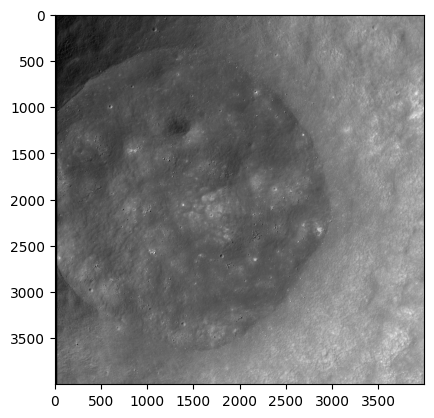

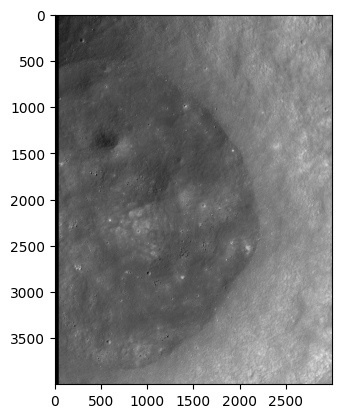

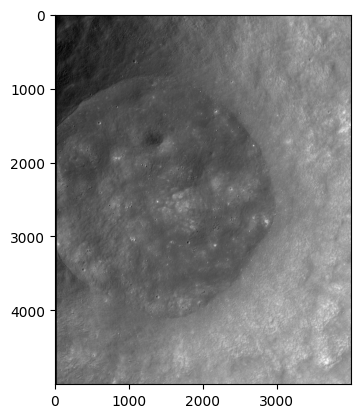

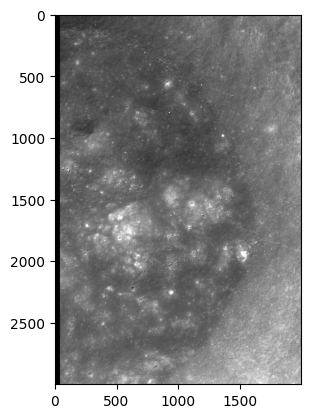

Shift-and-Add(ドリズル)開始: 入力4枚, 出力サイズ(8000, 8000)
  画像0: 重ね合わせ完了
  画像1: 重ね合わせ完了
  画像2: 重ね合わせ完了
  画像3: 重ね合わせ完了


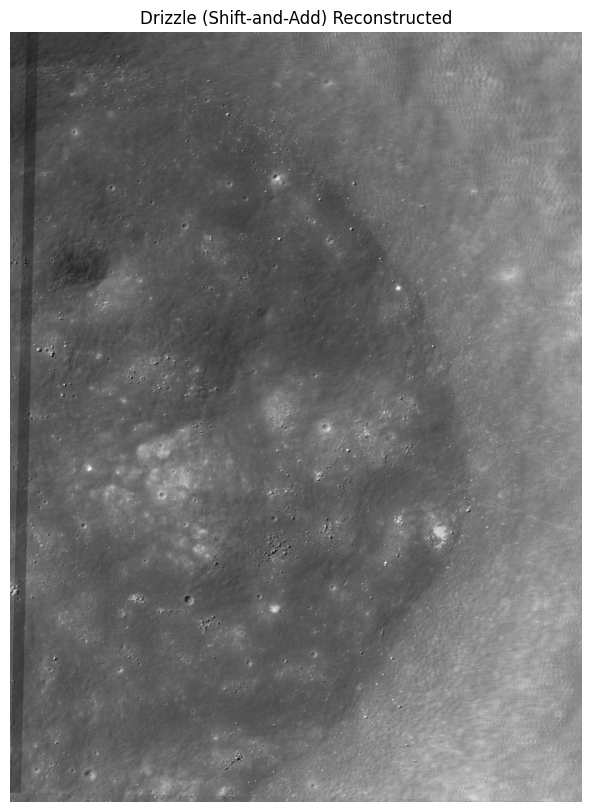

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23492 (\N{CJK UNIFIED IDEOGRAPH-5BC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.pri

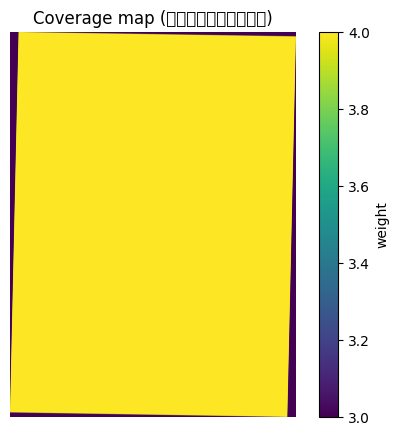

今0回目
今5回目


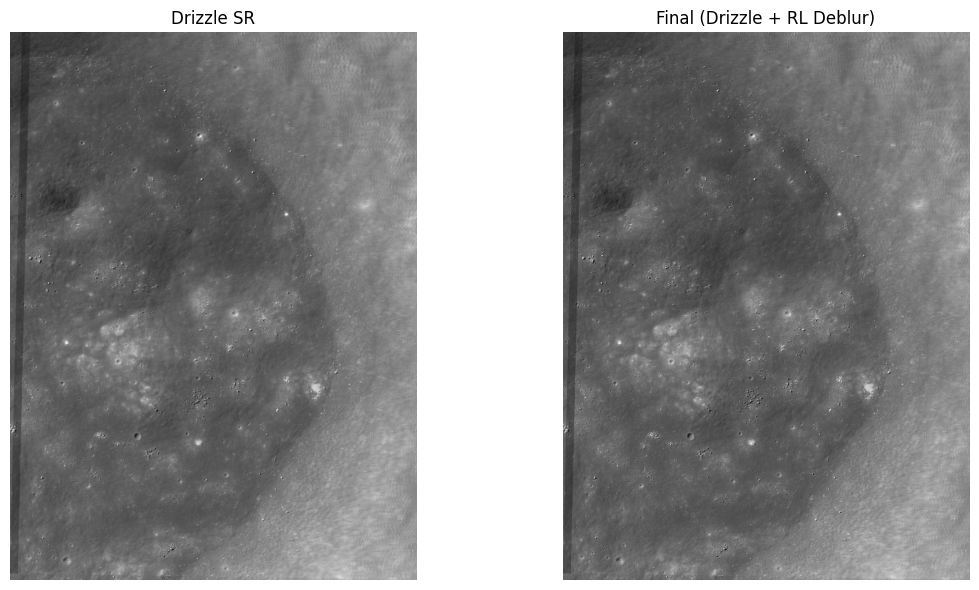

In [ ]:
import glob
import os
import cv2
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

IMAGE_DIR = '/content/drive/My Drive/Graduate/Craters0727'

"""## 位置合わせ"""

# ------------------------------------------------------------------
# 位置合わせ方式の切り替え
#   "sift" : Sobel+SIFT+FLANNでホモグラフィを推定 (回転・スケール・shearも推定可能)
#   "ecc"  : 位相相関の代わりにECCアルゴリズムで直接推定 (繰り返し模様に強い)
# まずは "sift" のままDEBUG_SHOW_MATCHESで確認し、ダメそうなら "ecc" に変更してください。
# ------------------------------------------------------------------
ALIGNMENT_METHOD = "sift"   # "sift" or "ecc"
DEBUG_SHOW_MATCHES = False  # Trueにするとマッチング結果を可視化(sift方式のみ)

# 絶対的なホモグラフィ妥当性チェックの閾値
# (月面のような近距離の連写では、scaleが1から大きくズレたりshearが大きいのは物理的にありえない)
SCALE_MIN, SCALE_MAX = 0.85, 1.18
MAX_SHEAR = 0.15


class SobelPreprocessor:
    @staticmethod
    def apply(img):
        grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = np.sqrt(grad_x**2 + grad_y**2)
        return cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


class FeatureMatcher:
    def __init__(self):
        self.detector = cv2.SIFT_create()
        index_params = dict(algorithm=1, trees=5)
        search_params = dict(checks=50)
        self.matcher = cv2.FlannBasedMatcher(index_params, search_params)

    def detect_and_match(self, img1, img2):
        sobel1 = SobelPreprocessor.apply(img1)
        sobel2 = SobelPreprocessor.apply(img2)
        kp1, des1 = self.detector.detectAndCompute(sobel1, None)
        kp2, des2 = self.detector.detectAndCompute(sobel2, None)
        matches = self.matcher.knnMatch(des1, des2, k=2)
        good = [m for m, n in matches if m.distance < 0.75 * n.distance]
        return kp1, kp2, good, sobel1, sobel2


class ImageAligner:
    def __init__(self, method="sift"):
        self.method = method
        self.matcher = FeatureMatcher()

    def align_full(self, img1, img2, debug_label=None):
        """
        img1: 基準画像 (base)
        img2: 位置合わせ対象画像
        戻り値のHは「img2の座標 -> img1(base)の座標」への3x3変換行列。
        """
        if self.method == "sift":
            return self._align_sift(img1, img2, debug_label)
        elif self.method == "ecc":
            return self._align_ecc(img1, img2)
        else:
            raise ValueError(f"Unknown alignment method: {self.method}")

    def _align_sift(self, img1, img2, debug_label=None):
        kp1, kp2, good_matches, sobel1, sobel2 = self.matcher.detect_and_match(img1, img2)

        if len(good_matches) < 4:
            raise RuntimeError("Not enough matches to compute homography.")

        pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        H, mask = cv2.findHomography(
            pts2, pts1, cv2.RANSAC,
            ransacReprojThreshold=3.0, maxIters=5000, confidence=0.995,
        )
        if H is None:
            raise RuntimeError("Homography computation failed.")

        if debug_label is not None:
            inlier_matches = [m for m, keep in zip(good_matches, mask.ravel()) if keep]
            img_matches = cv2.drawMatches(
                sobel1, kp1, sobel2, kp2, inlier_matches, None,
                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
            )
            plt.figure(figsize=(15, 7))
            plt.imshow(img_matches, cmap='gray')
            plt.title(f"Inlier matches: {debug_label} (n={len(inlier_matches)})")
            plt.axis('off')
            plt.show()

        origin_pt = np.array([[[0.0, 0.0]]], dtype=np.float32)
        transformed_origin = cv2.perspectiveTransform(origin_pt, H)
        dx = transformed_origin[0][0][0]
        dy = transformed_origin[0][0][1]

        return H, dx, dy

    def _align_ecc(self, img1, img2, warp_mode=cv2.MOTION_EUCLIDEAN,
                    iterations=500, eps=1e-7):
        """
        位相相関の代わりにECCアルゴリズムで直接位置合わせする。
        繰り返し模様(クレーター)が多く特徴点マッチングが不安定な場合の代替手段。
        MOTION_TRANSLATION: 並進のみ / MOTION_EUCLIDEAN: 並進+回転 / MOTION_AFFINE: 並進+回転+スケール+shear
        """
        img1_f = img1.astype(np.float32) / 255.0
        img2_f = img2.astype(np.float32) / 255.0

        warp_matrix = np.eye(2, 3, dtype=np.float32)
        criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, iterations, eps)

        try:
            _, warp_matrix = cv2.findTransformECC(
                img1_f, img2_f, warp_matrix, warp_mode, criteria
            )
        except cv2.error as e:
            raise RuntimeError(f"ECC alignment failed: {e}")

        # warp_matrixは「img1座標 -> img2座標」の変換なので、
        # 他の処理系(img2 -> img1=base)に合わせるため逆行列にする
        H_2x3_inv = cv2.invertAffineTransform(warp_matrix)
        H = np.vstack([H_2x3_inv, [0, 0, 1]]).astype(np.float64)

        origin_pt = np.array([[[0.0, 0.0]]], dtype=np.float32)
        transformed_origin = cv2.perspectiveTransform(origin_pt, H.astype(np.float32))
        dx = transformed_origin[0][0][0]
        dy = transformed_origin[0][0][1]

        return H, dx, dy


# パスを取得
path = glob.glob(os.path.join(IMAGE_DIR, '*.tif'))
path = sorted(path, key=os.path.getmtime)

raw_images = []
for p in path:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        raw_images.append(img)
    else:
        print(f"画像の読み込みに失敗しました: {p}")

if not raw_images:
    raise RuntimeError(f"画像が見つかりませんでした。IMAGE_DIR='{IMAGE_DIR}' を確認してください.")

aligner = ImageAligner(method=ALIGNMENT_METHOD)


def align_all_to_base(raw_images, base_idx, aligner):
    base_img = raw_images[base_idx]
    n = len(raw_images)
    offsets = [None] * n
    H_list = [None] * n
    offsets[base_idx] = (0.0, 0.0)
    H_list[base_idx] = np.eye(3, dtype=np.float64)

    for i, img in enumerate(raw_images):
        if i == base_idx:
            continue
        try:
            label = f"base={base_idx}, img={i}" if DEBUG_SHOW_MATCHES else None
            H, dx, dy = aligner.align_full(base_img, img, debug_label=label)
        except RuntimeError as e:
            print(f"  画像{i}: 位置合わせ失敗 ({e})")
            offsets[i] = (float('inf'), float('inf'))
            H_list[i] = np.eye(3, dtype=np.float64)
            continue
        print(f"  画像{i}: dx={dx:.2f}, dy={dy:.2f}")
        offsets[i] = (dx, dy)
        H_list[i] = H

    return offsets, H_list

"""## いらない画像の抽出"""

def homography_scale_shear(H):
    A = H[:2, :2]
    sx = np.sqrt(A[0, 0] ** 2 + A[1, 0] ** 2)
    sy = np.sqrt(A[0, 1] ** 2 + A[1, 1] ** 2)
    shear = abs(A[0, 1]) + abs(A[1, 0])
    return sx, sy, shear


def is_physically_plausible(H, scale_range=(SCALE_MIN, SCALE_MAX), max_shear=MAX_SHEAR):
    """
    相対的な外れ値判定とは別に、絶対値でホモグラフィの妥当性をチェックする。
    全フレームのマッチングが壊れている場合、相対比較(中央値との差)だけでは
    「全部おかしいから相対的には普通」と誤判定されてしまうため、これが必要。
    """
    sx, sy, shear = homography_scale_shear(H)
    return (scale_range[0] <= sx <= scale_range[1] and
            scale_range[0] <= sy <= scale_range[1] and
            shear <= max_shear)


def filter_valid_images_statistical(images, offsets, H_list, base_idx=0,
                                      min_overlap_ratio=0.3, outlier_threshold=3.0):
    h, w = images[0].shape[:2]

    scales_x, scales_y, shears = [], [], []
    for H in H_list:
        sx, sy, shear = homography_scale_shear(H)
        scales_x.append(sx)
        scales_y.append(sy)
        shears.append(shear)

    scales_x = np.array(scales_x)
    scales_y = np.array(scales_y)
    shears = np.array(shears)

    def is_outlier(values, idx, thresh):
        median = np.median(values)
        mad = np.median(np.abs(values - median)) + 1e-8
        return abs(values[idx] - median) / mad > thresh

    valid_indices = []
    for i, (dx, dy) in enumerate(offsets):
        if i == base_idx:
            valid_indices.append(i)
            continue

        overlap_w = w - abs(dx)
        overlap_h = h - abs(dy)
        overlap_ratio = (overlap_w * overlap_h) / (w * h) if overlap_w > 0 and overlap_h > 0 else 0.0

        sx_outlier = is_outlier(scales_x, i, outlier_threshold)
        sy_outlier = is_outlier(scales_y, i, outlier_threshold)
        sh_outlier = is_outlier(shears, i, outlier_threshold)
        relative_ok = not (sx_outlier or sy_outlier or sh_outlier)

        absolute_ok = is_physically_plausible(H_list[i])

        h_ok = relative_ok and absolute_ok

        if overlap_ratio >= min_overlap_ratio and h_ok:
            valid_indices.append(i)
            print(f"画像{i}: 採用 (scale=({scales_x[i]:.4f},{scales_y[i]:.4f}), shear={shears[i]:.4f})")
        else:
            reason = []
            if overlap_ratio < min_overlap_ratio:
                reason.append("重なり不足")
            if not relative_ok:
                reason.append(f"Hが相対的な外れ値(scale=({scales_x[i]:.4f},{scales_y[i]:.4f}), shear={shears[i]:.4f})")
            if not absolute_ok:
                reason.append(f"Hが物理的にありえない値(scale=({scales_x[i]:.4f},{scales_y[i]:.4f}), shear={shears[i]:.4f})")
            print(f"画像{i}: 除外 ({', '.join(reason)})")

    return valid_indices


MIN_OVERLAP_RATIO = 0.3
OUTLIER_THRESHOLD = 3.0
MIN_REQUIRED_IMAGES = 6

best_base_idx = None
best_valid_indices = []
best_offsets = None
best_H_list = None

for base_idx in range(len(raw_images)):
    print(f"\n=== 画像{base_idx}を基準にして位置合わせを試します ===")
    offsets, H_list = align_all_to_base(raw_images, base_idx, aligner)
    valid_indices = filter_valid_images_statistical(
        raw_images, offsets, H_list, base_idx=base_idx,
        min_overlap_ratio=MIN_OVERLAP_RATIO,
        outlier_threshold=OUTLIER_THRESHOLD,
    )
    print(f"--- 画像{base_idx}を基準: 採用 {len(valid_indices)}枚 {valid_indices} ---")

    if len(valid_indices) > len(best_valid_indices):
        best_base_idx = base_idx
        best_valid_indices = valid_indices
        best_offsets = offsets
        best_H_list = H_list

    if len(best_valid_indices) >= MIN_REQUIRED_IMAGES:
        print(f"十分な枚数({len(best_valid_indices)}枚)が確保できたので探索を打ち切ります.")
        break
else:
    print(
        f"\nどの基準画像を試しても目標の{MIN_REQUIRED_IMAGES}枚には届きませんでした."
        f"最も採用枚数が多かった基準画像(画像{best_base_idx})を使用します."
    )

base_idx = best_base_idx
valid_indices = best_valid_indices
offsets = best_offsets
H_list = best_H_list

if len(valid_indices) < 2:
    raise RuntimeError(
        f"信頼できる位置合わせ結果が{len(valid_indices)}枚しか得られませんでした。\n"
        f"ALIGNMENT_METHOD='{ALIGNMENT_METHOD}'で失敗している可能性が高いです。\n"
        f"DEBUG_SHOW_MATCHES=Trueにしてマッチングを確認するか、"
        f"ALIGNMENT_METHOD='ecc'に切り替えて再実行してください。"
    )

print(f"\n>>> 最終的に画像{base_idx}を基準として採用します。有効画像: {valid_indices} ({len(valid_indices)}枚)")

filtered_images = [raw_images[i] for i in valid_indices]
filtered_H_list = [H_list[i] for i in valid_indices]

"""## 重なり領域(オーバーラップ)の計算 (回転・スケールも考慮)"""

def compute_overlap_bbox(images, H_list, base_shape):
    """
    各画像の四隅をHで変換し、base画像座標系での共通重なり矩形(軸並行)を求める。
    単純なdx,dyの並進だけでなく、回転・スケールも考慮した重なり範囲になる。
    """
    hb, wb = base_shape
    x1s, x2s, y1s, y2s = [], [], [], []

    for img, H in zip(images, H_list):
        h, w = img.shape[:2]
        corners = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype=np.float32).reshape(-1, 1, 2)
        warped_corners = cv2.perspectiveTransform(corners, H.astype(np.float32)).reshape(-1, 2)
        x1s.append(warped_corners[:, 0].min())
        x2s.append(warped_corners[:, 0].max())
        y1s.append(warped_corners[:, 1].min())
        y2s.append(warped_corners[:, 1].max())

    crop_x1 = max(0.0, max(x1s))
    crop_x2 = min(float(wb), min(x2s))
    crop_y1 = max(0.0, max(y1s))
    crop_y2 = min(float(hb), min(y2s))

    return crop_x1, crop_x2, crop_y1, crop_y2


base_h, base_w = raw_images[base_idx].shape[:2]
crop_x1, crop_x2, crop_y1, crop_y2 = compute_overlap_bbox(filtered_images, filtered_H_list, (base_h, base_w))

if crop_x2 <= crop_x1 or crop_y2 <= crop_y1:
    raise RuntimeError(
        "有効な重なり領域が見つかりませんでした。\n"
        "採用された画像のHが妥当でも重なりが無い場合は、そもそも撮影範囲が\n"
        "大きくズレている可能性があります。DEBUG_SHOW_MATCHES=Trueで確認してください。"
    )

print(f"重なり範囲 (base座標系): X({crop_x1:.1f}:{crop_x2:.1f}), Y({crop_y1:.1f}:{crop_y2:.1f})")
print(f"重なり領域サイズ: ({crop_y2 - crop_y1:.1f}, {crop_x2 - crop_x1:.1f})")

"""## 明るさの調節 (元画像に対して実施)"""

def normalize_brightness_global(images):
    ref = images[0].astype(np.float32)
    ref_mean, ref_std = np.mean(ref), np.std(ref)

    norm_images = []
    for img in images:
        img_f = img.astype(np.float32)
        m, s = np.mean(img_f), np.std(img_f)
        adjusted = (img_f - m) * (ref_std / (s + 1e-8)) + ref_mean
        norm_images.append(np.clip(adjusted, 0, 255))
    return norm_images

norm_images = normalize_brightness_global(filtered_images)

for img in norm_images:
    plt.imshow(img, cmap='gray')
    plt.show()

"""## RL法用 ガウスPSFの定義"""

def create_gaussian_psf(size, sigma):
    """2DガウスPSF（点広がり関数）を作成"""
    kx = cv2.getGaussianKernel(size, sigma)
    psf = np.outer(kx, kx)
    return psf / np.sum(psf)

# RL法で使用する標準的な低解像度用PSFを作成
psf_size = 15
base_sigma = 1.0  # 標準的なボケ量（必要に応じて1.0〜1.5程度で調整）
psf_target = create_gaussian_psf(psf_size, base_sigma)

"""## Shift-and-Add（ドリズル）法 -- ホモグラフィ全体を使うよう修正"""

def drizzle_shift_and_add_homography(images, H_list, base_shape, crop_bbox, K=2,
                                       interpolation=cv2.INTER_LINEAR):
    """
    Shift-and-Add（ドリズル）法による超解像。
    各画像の完全なホモグラフィH(画像i座標 -> base画像座標)をそのまま
    K倍精度のキャンバスに反映する。最後にcrop_bbox(base座標系での
    共通重なり範囲)をK倍してクロップする。
    """
    hb, wb = base_shape
    H_out, W_out = hb * K, wb * K

    S = np.array([
        [K, 0, 0],
        [0, K, 0],
        [0, 0, 1],
    ], dtype=np.float64)

    acc = np.zeros((H_out, W_out), dtype=np.float64)
    weight_total = np.zeros((H_out, W_out), dtype=np.float64)

    print(f"Shift-and-Add(ドリズル)開始: 入力{len(images)}枚, 出力サイズ({H_out}, {W_out})")

    for i, (img, H) in enumerate(zip(images, H_list)):
        img_f = img.astype(np.float32)

        H_scaled = (S @ H).astype(np.float32)

        warped = cv2.warpPerspective(
            img_f, H_scaled, (W_out, H_out),
            flags=interpolation,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )

        ones = np.ones_like(img_f, dtype=np.float32)
        warped_weight = cv2.warpPerspective(
            ones, H_scaled, (W_out, H_out),
            flags=interpolation,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )

        acc += warped.astype(np.float64) * warped_weight.astype(np.float64)
        weight_total += warped_weight.astype(np.float64)

        print(f"  画像{i}: 重ね合わせ完了")

    coverage = weight_total.astype(np.float32)
    reconstructed = (acc / (weight_total + 1e-8)).astype(np.float32)

    zero_coverage_ratio = np.mean(coverage < 1e-6)
    if zero_coverage_ratio > 0:
        print(
            f"警告: 出力画素の {zero_coverage_ratio*100:.2f}% がどのフレームからも"
            f"データを得られていません（クロップ範囲やオフセットを確認してください）。"
        )

    cx1, cx2, cy1, cy2 = crop_bbox
    x1, x2 = int(round(cx1 * K)), int(round(cx2 * K))
    y1, y2 = int(round(cy1 * K)), int(round(cy2 * K))

    reconstructed_cropped = reconstructed[y1:y2, x1:x2]
    coverage_cropped = coverage[y1:y2, x1:x2]

    return reconstructed_cropped, coverage_cropped


result, coverage_map = drizzle_shift_and_add_homography(
    norm_images,
    filtered_H_list,
    (base_h, base_w),
    (crop_x1, crop_x2, crop_y1, crop_y2),
    K=2,
    interpolation=cv2.INTER_LINEAR,
)

result_clipped = np.clip(result, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 10))
plt.imshow(result_clipped, cmap="gray")
plt.title("Drizzle (Shift-and-Add) Reconstructed")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(coverage_map, cmap="viridis")
plt.title("Coverage map (寄与フレーム数の重み)")
plt.colorbar(label="weight")
plt.axis("off")
plt.show()

"""## RL法"""

def richardson_lucy(image, psf, iterations=15):
    """Richardson-Lucy デコンボリューション"""
    image = image.astype(np.float32) / 255.0
    psf = psf.astype(np.float32)
    psf_mirror = np.flip(psf)

    latent = np.copy(image)
    eps = 1e-12

    for i in range(iterations):
        relative_blur = image / (scipy.signal.convolve2d(latent, psf, mode='same') + eps)
        error_factor = scipy.signal.convolve2d(relative_blur, psf_mirror, mode='same')
        latent *= error_factor
        if i % 5 == 0:
            print(f"今{i}回目")

    return np.clip(latent * 255.0, 0, 255).astype(np.uint8)

psf_size = 15
target_sigma = 1.2
kx = cv2.getGaussianKernel(psf_size, target_sigma)
psf_target = np.outer(kx, kx)
psf_target /= np.sum(psf_target)

K = 2
psf_target_sr = cv2.resize(psf_target, (0, 0), fx=K, fy=K, interpolation=cv2.INTER_CUBIC)
psf_target_sr /= np.sum(psf_target_sr)

final_deblurred = richardson_lucy(result_clipped, psf_target_sr, iterations=10)

cv2.imwrite("SR_Drizzle_RL_Deblurred.png", final_deblurred)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Drizzle SR")
plt.imshow(result_clipped, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Final (Drizzle + RL Deblur)")
plt.imshow(final_deblurred, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()